Nome: Sofia Balerini de Vasconcellos

RA: 299904

Curso: Doutorado eng. elétrica


#Contagem automática de moedas em imagens

Este notebook apresenta uma demonstração de como utilizar técnicas de processamento de imagens para identificar e somar valores de moedas presentes em uma imagem.

Serão utilizadas técnicas como:
- Conversão para escala de cinza
- Limiarização (thresholding)
- Operações morfológicas
- Componentes conexos

Ao final, será possível identificar automaticamente o valor total das moedas na imagem.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import requests
import os

In [ ]:
def download_image(url):
    filename = os.path.basename(url)
    if not os.path.exists(filename):
        r = requests.get(url)
        with open(filename, "wb") as f:
            f.write(r.content)
    return filename

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

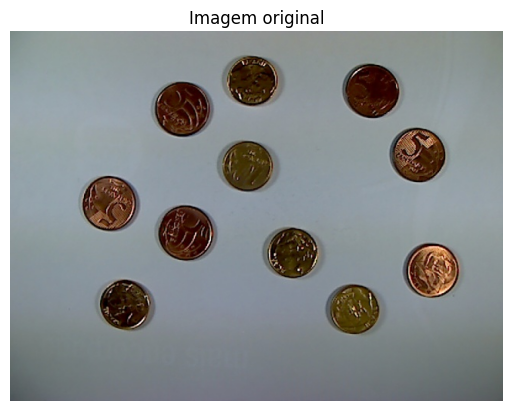

In [ ]:
url = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/80.jpg"
filename = download_image(url)

img = mpimg.imread(filename)

plt.imshow(img)
plt.title("Imagem original")
plt.axis('off')

A imagem é convertida para escala de cinza para simplificar o processamento, reduzindo os três canais RGB para apenas um canal de intensidade.

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

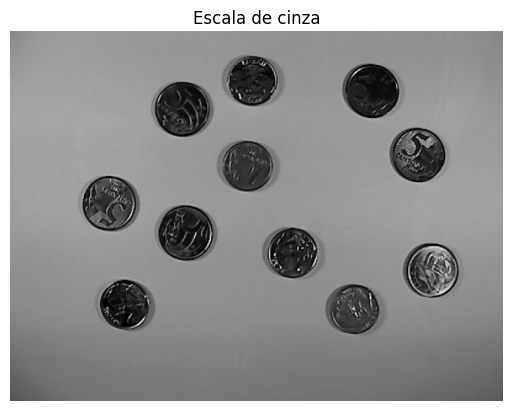

In [ ]:
img_gray = np.uint8(0.3*img[:,:,0] + 0.59*img[:,:,1] + 0.11*img[:,:,2])

plt.imshow(img_gray, cmap='gray')
plt.title("Escala de cinza")
plt.axis('off')

A limiarização separa automaticamente as moedas do fundo.
O método de Otsu calcula um limiar ótimo baseado no histograma da imagem.

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

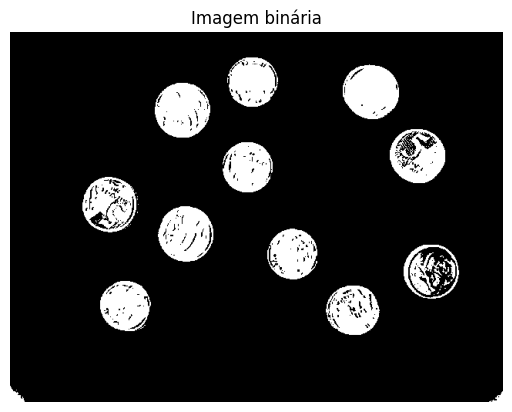

In [ ]:
_, bin_img = cv2.threshold(255 - img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(bin_img, cmap='gray')
plt.title("Imagem binária")
plt.axis('off')

Aplicamos operações morfológicas para melhorar a segmentação:

- Closing: preenche buracos nas moedas  
- Opening: remove pequenos ruídos

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

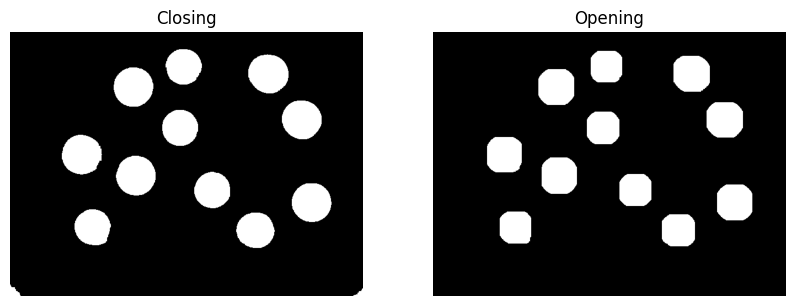

In [ ]:
kernel_cl = np.ones((15,15), np.uint8)
kernel_op = np.ones((31,31), np.uint8)

close = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel_cl)
open_img = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(close, cmap='gray')
plt.title("Closing")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(open_img, cmap='gray')
plt.title("Opening")
plt.axis('off')

Identificamos cada moeda individualmente usando componentes conexos.
Cada objeto segmentado recebe um rótulo.

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

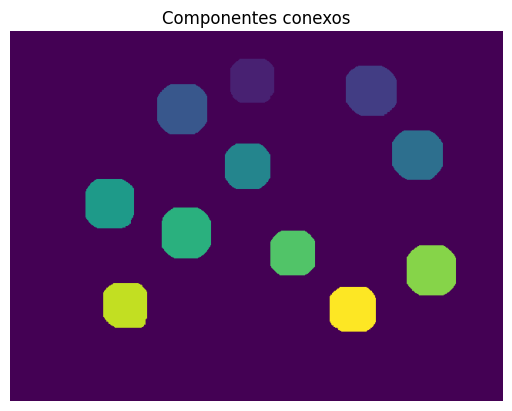

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(open_img, 4)

plt.imshow(labels)
plt.title("Componentes conexos")
plt.axis('off')

Cada moeda é classificada com base na sua área (número de pixels).
Moedas maiores possuem mais pixels.

In [ ]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

list_npixels = calc_npixels_label(labels, num_labels)

Número de moedas: 11
Valor total: 80


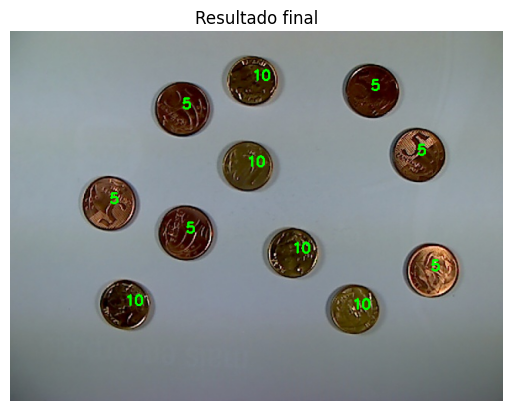

In [ ]:
img = img.copy()

soma = 0

for i, p in enumerate(list_npixels):
    x = int(centroids[i+1][0])
    y = int(centroids[i+1][1])

    if p < 3500:
        valor = 10
    elif p > 4600:
        valor = 25
    else:
        valor = 5

    soma += valor
    cv2.putText(img, str(valor), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

plt.imshow(img)
plt.title("Resultado final")
plt.axis('off')

print("Número de moedas:", len(list_npixels))
print("Valor total:", soma)

Foi possível identificar e classificar automaticamente as moedas presentes na imagem utilizando técnicas de processamento de imagens.

As etapas de limiarização e morfologia foram essenciais para uma boa segmentação, enquanto a análise de componentes conexos permitiu a identificação individual de cada moeda.

A classificação baseada na área mostrou-se eficaz para diferenciar os valores das moedas.